# Transport Physics: Landauer-Style Chain Transmission

This notebook computes a simple coherent-transport transmission curve for a finite chain coupled to left and right leads. The solver uses Green's functions and compares exact inverses with inverse-polynomial approximations of the positive Hermitian denominator.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.spectral import apply_polynomial_to_hermitian, eigh_hermitian
from qsvt.hamiltonians import tight_binding_chain
from qsvt.matrix_functions import design_resolvent_polynomials

n = 4
H = tight_binding_chain(n)

Gamma_L = np.zeros((n, n))
Gamma_L[0, 0] = 0.55
Gamma_R = np.zeros((n, n))
Gamma_R[-1, -1] = 0.55
eta = 0.5 * (Gamma_L[0, 0] + Gamma_R[-1, -1]) / 2.0
evals, _ = eigh_hermitian(H)
scale = np.max(np.abs(evals))
A = H / scale

energies = np.linspace(-2.4, 2.4, 90)
T_exact = []
T_poly = []
for E in energies:
    G = np.linalg.inv((E + 1j * eta) * np.eye(n) - H)
    T_exact.append(np.real(np.trace(Gamma_L @ G @ Gamma_R @ G.conj().T)))

    real_coeffs, imag_coeffs = design_resolvent_polynomials(
        omega=E, eta=eta, scale=scale, degree=38
    )
    G_approx = apply_polynomial_to_hermitian(
        A, real_coeffs
    ) + 1j * apply_polynomial_to_hermitian(A, imag_coeffs)
    T_poly.append(np.real(np.trace(Gamma_L @ G_approx @ Gamma_R @ G_approx.conj().T)))

curve_error = np.linalg.norm(np.array(T_poly) - np.array(T_exact)) / np.linalg.norm(
    T_exact
)
curve_error

np.float64(0.0014913927900937186)

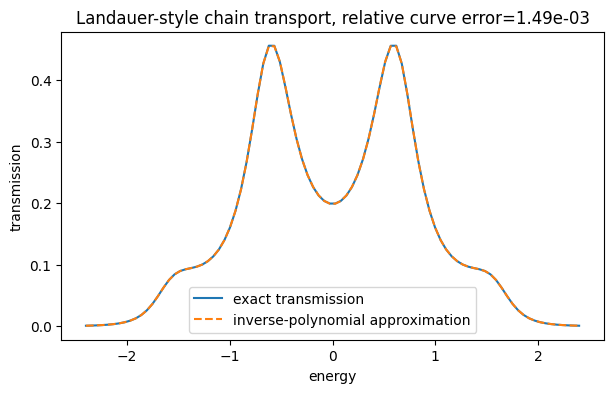

In [2]:
plt.figure(figsize=(7, 4))
plt.plot(energies, T_exact, label="exact transmission")
plt.plot(energies, T_poly, "--", label="inverse-polynomial approximation")
plt.xlabel("energy")
plt.ylabel("transmission")
plt.title(f"Landauer-style chain transport, relative curve error={curve_error:.2e}")
plt.legend()
plt.show()